# Stress-Testing Fleet Electrification with Monte Carlo Simulation (SOLUTION)

## Scenario

Haul & Charge Co., an urban delivery company, evaluates three strategies for its
20-truck fleet over a 5-year horizon: Buy electric trucks outright, Lease them, or
Hold (keep diesel as baseline). A 10,000-draw Monte Carlo simulation across uncertain
electricity rates, utilization, maintenance savings, and resale values quantifies the
distribution of outcomes and identifies which strategy is more robust.

## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../monte-carlo-simulation-starter/data/eia_commercial_rate.csv"

N_TRUCKS    = 20
BUY_PRICE   = 85_000
LEASE_RATE  = 1_100
DIESEL_GAL  = 4.50
DIESEL_MPG  = 5.0
EV_KWH_MILE = 1.2
DISC_RATE   = 0.06
YEARS       = 5

N_SIMS = 10_000
RNG    = np.random.default_rng(42)

OPTIONS = ["Buy", "Lease", "Hold"]

## 1. Electricity rate distribution

In [3]:
rates = pd.read_csv(DATA_PATH, parse_dates=["date"])
rates

,date,rate_per_kwh
0,2015-01-01,0.138
1,2015-02-01,0.138
2,2015-03-01,0.136
3,2015-04-01,0.137
4,2015-05-01,0.137
...,...,...
130,2025-12-01,0.189
131,2026-01-01,0.192
132,2026-02-01,0.189
133,2026-03-01,0.190


In [4]:
recent    = rates[rates["date"].dt.year >= 2019]
ELEC_MEAN = recent["rate_per_kwh"].mean()
ELEC_SD   = recent["rate_per_kwh"].std()

print(f"Electricity rate: mean=${ELEC_MEAN:.4f}/kWh, SD=${ELEC_SD:.4f}/kWh")

Electricity rate: mean=$0.1584/kWh, SD=$0.0199/kWh


## 2. Fleet NPV model

In [5]:
_PV_FACTOR       = sum(1 / (1 + DISC_RATE) ** t for t in range(1, YEARS + 1))
_PV_RESALE_FACTOR = 1 / (1 + DISC_RATE) ** YEARS


def fleet_npv(option: str, elec_rate: float, annual_miles: float,
              maint_save: float, resale_pct: float) -> float:
    """5-year fleet NPV relative to keeping the diesel fleet ($)."""
    if option == "Hold":
        return 0.0

    fuel_save_annual  = N_TRUCKS * annual_miles * (DIESEL_GAL / DIESEL_MPG - EV_KWH_MILE * elec_rate)
    maint_save_annual = N_TRUCKS * maint_save
    annual_savings    = fuel_save_annual + maint_save_annual

    if option == "Buy":
        upfront = N_TRUCKS * BUY_PRICE
        resale  = N_TRUCKS * BUY_PRICE * resale_pct * _PV_RESALE_FACTOR
        return -upfront + annual_savings * _PV_FACTOR + resale

    if option == "Lease":
        lease_annual = N_TRUCKS * LEASE_RATE * 12
        return (annual_savings - lease_annual) * _PV_FACTOR

    raise ValueError(f"Unknown option: {option}")

## 3. Monte Carlo draws

In [6]:
sim_elec_rate    = RNG.normal(ELEC_MEAN, ELEC_SD, N_SIMS).clip(0.08, 0.40)
sim_annual_miles = RNG.normal(30_000, 4_000, N_SIMS).clip(10_000, 50_000)
sim_maint_save   = RNG.normal(2_500, 400, N_SIMS).clip(0, 5_000)
sim_resale_pct   = RNG.normal(0.40, 0.10, N_SIMS).clip(0.10, 0.70)

## 4. Evaluate across all draws

In [7]:
sim_profits = pd.DataFrame({
    opt: [fleet_npv(opt, e, m, s, r)
          for e, m, s, r in zip(sim_elec_rate, sim_annual_miles, sim_maint_save, sim_resale_pct)]
    for opt in OPTIONS
})
sim_profits.head()

,Buy,Lease,Hold
0,6.520622e+05,8.603481e+05,0.0
1,1.122509e+06,1.208331e+06,0.0
2,2.514508e+05,5.022853e+05,0.0
3,5.791157e+05,7.497906e+05,0.0
4,1.102777e+06,1.213598e+06,0.0


## 5. Distribution plot

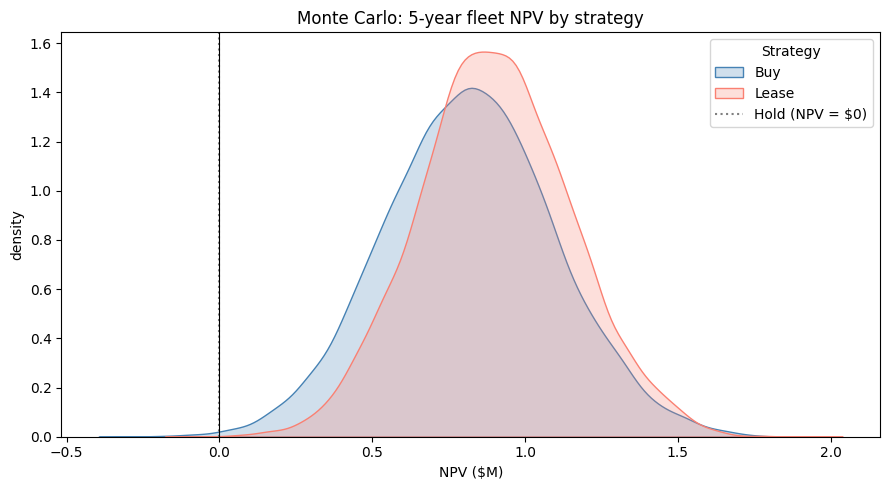

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for opt, color in [("Buy", "steelblue"), ("Lease", "salmon"), ("Hold", "grey")]:
    if opt == "Hold":
        ax.axvline(0, color=color, linestyle=":", linewidth=1.5, label="Hold (NPV = $0)")
    else:
        sns.kdeplot(sim_profits[opt] / 1e6, label=opt, fill=True, alpha=0.25, color=color, ax=ax)

ax.axvline(0, color="black", linewidth=0.8)
ax.set(title="Monte Carlo: 5-year fleet NPV by strategy",
       xlabel="NPV ($M)", ylabel="density")
ax.legend(title="Strategy")
plt.tight_layout()
plt.show()

## 6. Summary statistics

In [9]:
summary = pd.DataFrame({
    "Mean ($K)":  (sim_profits.mean() / 1e3).round(0),
    "SD ($K)":    (sim_profits.std()  / 1e3).round(0),
    "P5 ($K)":    (sim_profits.quantile(0.05) / 1e3).round(0),
    "P95 ($K)":   (sim_profits.quantile(0.95) / 1e3).round(0),
})
summary

,Mean ($K),SD ($K),P5 ($K),P95 ($K)
Buy,818.0,281.0,361.0,1291.0
Lease,899.0,250.0,488.0,1321.0
Hold,0.0,0.0,0.0,0.0


## 7. P(Buy > Lease) and P(NPV > 0)

In [10]:
p_buy_gt_lease = (sim_profits["Buy"] > sim_profits["Lease"]).mean()
p_buy_pos      = (sim_profits["Buy"]   > 0).mean()
p_lease_pos    = (sim_profits["Lease"] > 0).mean()

print(f"P(Buy > Lease):    {p_buy_gt_lease:.1%}")
print(f"P(Buy NPV > 0):   {p_buy_pos:.1%}")
print(f"P(Lease NPV > 0): {p_lease_pos:.1%}")

P(Buy > Lease):    26.1%
P(Buy NPV > 0):   99.8%
P(Lease NPV > 0): 100.0%


## 8. Interpretation

**Lease is the stronger strategy** on both mean NPV (~$899K vs. ~$818K for Buy) and
downside risk (lower SD, never goes negative in the simulation). Buy wins in only
~26% of simulations — specifically in scenarios where the year-5 resale value is
high enough to offset the larger upfront capital commitment. If Haul & Charge Co. expects
resale value to exceed roughly 50% of purchase price (above the mean assumption of
40%), Buy becomes competitive; below that, Lease dominates. Both EV options are
robustly better than Hold across essentially all simulated conditions.